In [2]:
import keras
import pandas

In [3]:
df = pandas.read_csv('/content/classData (1).csv')
print(df.head())

   G  C  B  A          Ia          Ib          Ic        Va        Vb  \
0  1  0  0  1 -151.291812   -9.677452   85.800162  0.400750 -0.132935   
1  1  0  0  1 -336.186183  -76.283262   18.328897  0.312732 -0.123633   
2  1  0  0  1 -502.891583 -174.648023  -80.924663  0.265728 -0.114301   
3  1  0  0  1 -593.941905 -217.703359 -124.891924  0.235511 -0.104940   
4  1  0  0  1 -643.663617 -224.159427 -132.282815  0.209537 -0.095554   

         Vc  
0 -0.267815  
1 -0.189099  
2 -0.151428  
3 -0.130570  
4 -0.113983  


In [7]:
def assign_class_label(row):
    g, c, b, a = row['G'], row['C'], row['B'], row['A']
    if g == 0 and c == 0 and b == 0 and a == 0:
        return 0 # No Fault
    elif g == 1 and c == 0 and b == 0 and a == 1:
        return 1 # LG fault (Between Phase A and Gnd)
    elif g == 0 and c == 0 and b == 1 and a == 1:
        return 2 # LL fault (Between Phase A and Phase B)
    elif g == 1 and c == 0 and b == 1 and a == 1:
        return 3 # LLG Fault (Between Phases A,B and ground)
    elif g == 0 and c == 1 and b == 1 and a == 1:
        return 4 # LLL Fault(Between all three phases)
    elif g == 1 and c == 1 and b == 1 and a == 1:
        return 5 # LLLG fault( Three phase symmetrical fault)
    else:
        return 5 # Assign any other unmapped combination to class 5 (LLLG fault) to ensure only 6 classes (0-5)

df['class_label'] = df.apply(assign_class_label, axis=1)

print("Value counts for the new 'class_label' column:")
print(df['class_label'].value_counts())

display(df.head())

Value counts for the new 'class_label' column:
class_label
0    2365
5    2137
3    1134
1    1129
4    1096
Name: count, dtype: int64


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,class_label
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,1
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,1
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,1
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,1
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,1


In [8]:
display(df.head())

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,class_label
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,1
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,1
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,1
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,1
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,1


In [9]:
df = df.drop(columns=['A', 'B', 'C', 'G'])
display(df.head())

,Ia,Ib,Ic,Va,Vb,Vc,class_label
0,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,1
1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,1
2,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,1
3,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,1
4,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,1


In [10]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values outside the bounds
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

numerical_cols = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

for col in numerical_cols:
    df = cap_outliers_iqr(df.copy(), col)

print("Outliers capped in numerical columns using IQR method.")
display(df.head())

Outliers capped in numerical columns using IQR method.


,Ia,Ib,Ic,Va,Vb,Vc,class_label
0,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,1
1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,1
2,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,1
3,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,1
4,-640.375860,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,1


In [11]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']]
y = df['class_label']

# Perform a train-test split (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (6288, 6)
X_test shape: (1573, 6)
y_train shape: (6288,)
y_test shape: (1573,)


In [13]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the fitted scaler
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for better readability and consistency
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("X_train_scaled head:")
display(X_train_scaled.head())
print("\nX_test_scaled head:")
display(X_test_scaled.head())

X_train_scaled head:


,Ia,Ib,Ic,Va,Vb,Vc
432,0.000000,0.523865,0.517646,0.598412,0.630616,0.295585
7196,0.494394,0.545898,0.456057,0.930284,0.646032,0.015167
3027,0.470665,0.923936,0.000000,0.984731,0.517707,0.101974
2937,0.415962,1.000000,0.000000,0.375499,0.473089,0.633311
5438,0.982907,0.594250,0.566558,0.560462,0.188079,0.775022



X_test_scaled head:


,Ia,Ib,Ic,Va,Vb,Vc
7096,0.431491,0.563707,0.595480,0.947565,0.036638,0.619895
1405,0.973956,0.610899,0.612069,0.548680,0.188521,0.783974
994,0.957478,0.610833,0.446464,0.219570,0.646601,0.581605
2024,0.078334,0.335409,0.393888,0.466525,0.790978,0.238043
5620,0.501091,0.559667,0.393456,0.730982,0.813010,0.004695


In [14]:
from keras.models import Sequential
from keras.layers import Dense

In [37]:
from keras.models import Sequential
from keras.layers import Dense, Input

# Get the number of features from the scaled training data
input_shape = X_train_scaled.shape[1]

# Get the number of unique classes for the output layer
# The problem statement defines 6 classes (0-5), so we explicitly set num_classes to 6
num_classes = 6

# Design the MLP model with 2 hidden layers
model = Sequential()
model.add(Input(shape=(input_shape,)))
model.add(Dense(64, activation='relu')) # First hidden layer
model.add(Dense(32, activation='relu')) # Second hidden layer
model.add(Dense(num_classes, activation='softmax')) # Output layer for multi-class classification

# Compile the model
# Using sparse_categorical_crossentropy because y_train are integer labels (0, 1, ..., 5)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,726 (10.65 KB)

 Trainable params: 2,726 (10.65 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
from keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Stop if val_loss doesn't improve for 10 epochs
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

print("Training the 2-hidden-layer model...")
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_split=0.2, callbacks=[early_stopping])
print("Model training complete!")

# The best weights are automatically restored by restore_best_weights=True

Training the 2-hidden-layer model...
Epoch 1/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4304 - loss: 1.3935 - val_accuracy: 0.5803 - val_loss: 1.0525
Epoch 2/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6829 - loss: 0.8412 - val_accuracy: 0.7727 - val_loss: 0.6425
Epoch 3/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7670 - loss: 0.5920 - val_accuracy: 0.7774 - val_loss: 0.5075
Epoch 4/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7881 - loss: 0.5003 - val_accuracy: 0.8203 - val_loss: 0.4510
Epoch 5/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7960 - loss: 0.4475 - val_accuracy: 0.8196 - val_loss: 0.4069
Epoch 6/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8064 - loss: 0.4114 - val_accuracy: 0.8156 - val_loss: 0.3764
Epoch 7/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8169 - loss: 0.3831 - val_accuracy: 0.8180 - val_loss: 0.3581
Epoch 8/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accur

In [40]:
loss_2_layers, accuracy_2_layers = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss (2-layers): {loss_2_layers:.4f}")
print(f"Test Accuracy (2-layers): {accuracy_2_layers:.4f}")

Test Loss (2-layers): 0.2122
Test Accuracy (2-layers): 0.8640


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report (2-layers):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       482
           1       0.94      1.00      0.97       242
           3       0.99      0.95      0.97       238
           4       0.53      0.33      0.40       199
           5       0.72      0.84      0.77       412

    accuracy                           0.86      1573
   macro avg       0.83      0.82      0.82      1573
weighted avg       0.85      0.86      0.85      1573



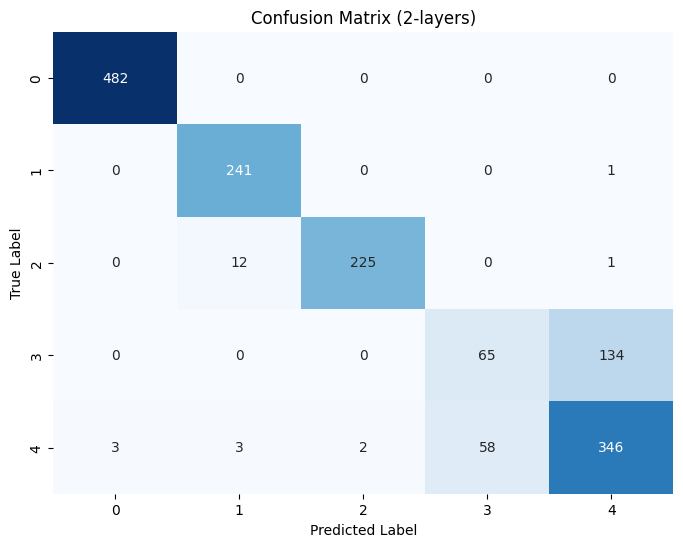

In [41]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predict probabilities for the test set
y_pred_probs_2_layers = model.predict(X_test_scaled)
# Get the predicted class labels by taking the argmax of the probabilities
y_pred_2_layers = np.argmax(y_pred_probs_2_layers, axis=1)

# Print classification report
print("\nClassification Report (2-layers):")
print(classification_report(y_test, y_pred_2_layers))

# Plot confusion matrix
cm_2_layers = confusion_matrix(y_test, y_pred_2_layers)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_2_layers, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (2-layers)')
plt.show()

In [30]:
from keras.models import Sequential
from keras.layers import Dense, Input

# Get the number of features from the scaled training data
input_shape = X_train_scaled.shape[1]

# The problem statement defines 6 classes (0-5), so num_classes is 6
num_classes = 6

# Design the MLP model with 3 hidden layers
model = Sequential()
model.add(Input(shape=(input_shape,)))
model.add(Dense(64, activation='relu'))  # First hidden layer
model.add(Dense(32, activation='relu'))  # Second hidden layer
model.add(Dense(16, activation='relu'))  # Third hidden layer
model.add(Dense(num_classes, activation='softmax')) # Output layer for multi-class classification

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,158 (12.34 KB)

 Trainable params: 3,158 (12.34 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Stop if val_loss doesn't improve for 10 epochs
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

print("Training the new 3-hidden-layer model...")
history_3_layers = model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_split=0.2, callbacks=[early_stopping])
print("Model training with 3 hidden layers complete!")

Training the new 3-hidden-layer model...
Epoch 1/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4940 - loss: 1.2902 - val_accuracy: 0.6049 - val_loss: 0.8702
Epoch 2/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7362 - loss: 0.6811 - val_accuracy: 0.8045 - val_loss: 0.5186
Epoch 3/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7885 - loss: 0.4866 - val_accuracy: 0.8045 - val_loss: 0.4117
Epoch 4/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8070 - loss: 0.4135 - val_accuracy: 0.8315 - val_loss: 0.3931
Epoch 5/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8107 - loss: 0.3823 - val_accuracy: 0.8275 - val_loss: 0.3561
Epoch 6/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8179 - loss: 0.3555 - val_accuracy: 0.8331 - val_loss: 0.3257
Epoch 7/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8312 - loss: 0.3399 - val_accuracy: 0.8339 - val_loss: 0.3261
Epoch 8/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - a

In [34]:
df.head()

,Ia,Ib,Ic,Va,Vb,Vc,class_label
0,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,1
1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,1
2,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,1
3,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,1
4,-640.375860,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,1


In [39]:
# Drop the 'class_label' column from the original DataFrame to prepare for inference
df_for_prediction = df.drop(columns=['class_label']).copy()

# Remove 'predicted_class' column if it exists, as requested by the user previously
if 'predicted_class' in df_for_prediction.columns:
    df_for_prediction = df_for_prediction.drop(columns=['predicted_class'])

# Scale the features using the same scaler fitted on the training data
df_scaled_for_prediction = scaler.transform(df_for_prediction)

# Make predictions using the trained model (currently the 2-hidden-layer model)
predictions_full_data_probs = model.predict(df_scaled_for_prediction)
predictions_full_data = np.argmax(predictions_full_data_probs, axis=1)

print("Predictions generated for the full dataset (without 'class_label' as input features).")
print("First 10 predictions (not added to DataFrame):")
print(predictions_full_data[:10])


246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions generated for the full dataset (without 'class_label' as input features).
First 10 predictions (not added to DataFrame):
[5 1 5 5 5 1 1 1 1 1]


In [43]:
df.head()

,Ia,Ib,Ic,Va,Vb,Vc,class_label
0,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,1
1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,1
2,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,1
3,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,1
4,-640.375860,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,1
